In [33]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def display_detected_fragments(image_path):
    img = image_path
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # 1. Convert to grayscale & apply bilateral filter to smooth wood/lines while preserving outer edges
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    filtered = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

    # 2. Canny edge detection
    edges = cv2.Canny(filtered, 25, 80)

    # 3. Connect edge boundaries
    kernel_dil = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    dilated = cv2.dilate(edges, kernel_dil, iterations=2)

    # 4. Extract external contours and fill them SOLID into a clean mask
    contours_edges, _ = cv2.findContours(
        dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    mask = np.zeros_like(gray)
    min_area = (h * w) * 0.01

    for c in contours_edges:
        if cv2.contourArea(c) > min_area:
            # Drawing with thickness = -1 fills the entire inner region solid, ignoring interior ruling lines
            cv2.drawContours(mask, [c], -1, 255, thickness=cv2.FILLED)

    # 5. Fill any remaining internal holes completely using floodFill
    mask_floodfill = mask.copy()
    h_m, w_m = mask.shape
    mask_padded = np.zeros((h_m + 2, w_m + 2), np.uint8)
    cv2.floodFill(mask_floodfill, mask_padded, (0, 0), 255)
    mask_inv = cv2.bitwise_not(mask_floodfill)
    solid_mask = cv2.bitwise_or(mask, mask_inv)

    # 6. Extract final clean external boundaries
    final_contours, _ = cv2.findContours(
        solid_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    fragments = [c for c in final_contours if cv2.contourArea(c) > min_area]

    print(f"Detected {len(fragments)} distinct paper fragments.")

    # 7. Visualization
    highlighted_img = img_rgb.copy()
    for idx, contour in enumerate(fragments):
        cv2.drawContours(highlighted_img, [contour], -1, (255, 0, 0), 4)

        x, y, pw, ph = cv2.boundingRect(contour)
        cv2.putText(
            highlighted_img,
            f"ID: {idx}",
            (x + 10, y + 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 0, 255),
            3,
        )

    plt.figure(figsize=(10, 8))
    plt.imshow(highlighted_img)
    plt.title(f"Detected Outlines (Total: {len(fragments)})")
    plt.axis("off")
    plt.show()




In [53]:
import cv2
import numpy as np


def normalize_image_brightness(image_or_path, brightness_limit=140, target_brightness=100):
    """
    Checks the brightness of an image. If it exceeds `brightness_limit` (e.g. flash turned ON),
    it calculates the required reduction factor and dims the image down to `target_brightness`.
    
    :param image_or_path: Path to the image file (str) or a loaded OpenCV BGR image array.
    :param brightness_limit: Brightness threshold (0-255). Images brighter than this are dimmed.
    :param target_brightness: Target average brightness after reduction (0-255).
    :return: Processed OpenCV BGR image array.
    """
    # 1. Load image if a file path is provided
    if isinstance(image_or_path, str):
        img = cv2.imread(image_or_path)
        if img is None:
            print(f"Error: Could not load image from path: {image_or_path}")
            return None
    else:
        img = image_or_path.copy()

    # 2. Convert to grayscale to measure average luminance
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    current_brightness = np.mean(gray)

    print(f"Detected Average Brightness: {current_brightness:.2f}")

    # 3. Check if brightness exceeds the limit (Flash condition)
    if current_brightness > brightness_limit:
        # Calculate reduction factor needed to reach target brightness
        brightness_factor = int(current_brightness - target_brightness)
        print(f"-> Image is too bright (Flash ON). Reducing brightness by factor: {brightness_factor}")
        
        # Safely reduce brightness
        adjusted_img = cv2.convertScaleAbs(img, alpha=1.0, beta=-brightness_factor)
        return adjusted_img
    else:
        print("-> Brightness is within optimal limits (Flash OFF). No adjustment needed.")
        return img

Detected Average Brightness: 84.29
-> Brightness is within optimal limits (Flash OFF). No adjustment needed.


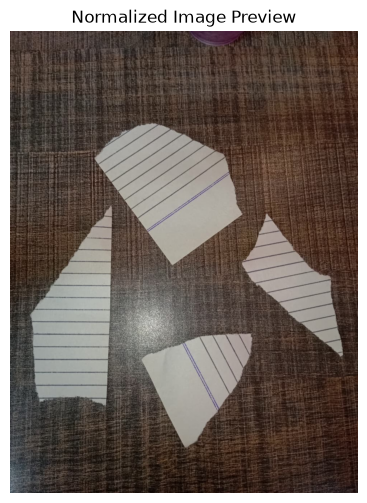

Detected 3 distinct paper fragments.


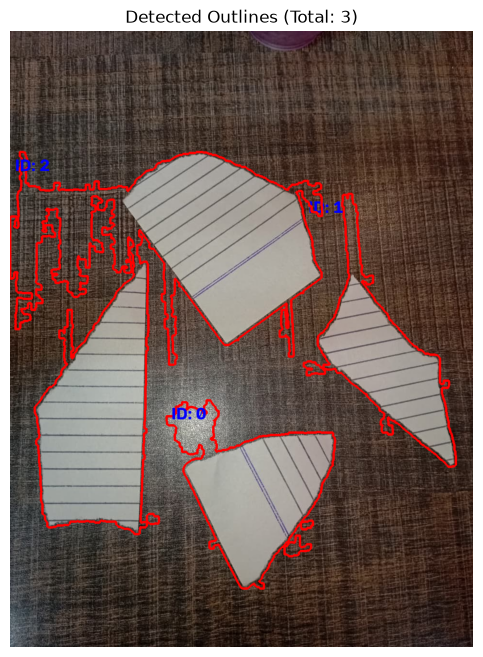

In [54]:
import matplotlib.pyplot as plt

def process_and_detect_fragments(image_path):
    # 1. Read input image
    img = cv2.imread(image_path)
    if img is None:
        print("Error loading image file.")
        return

    # 2. Adaptively fix flash/overexposure if needed
    # If mean brightness > 140, it dims it down to an average of 100
    normalized_img = normalize_image_brightness(
        img, 
        brightness_limit=140, 
        target_brightness=100
    )

    # 3. Display preview of normalized image
    preview_rgb = cv2.cvtColor(normalized_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(preview_rgb)
    plt.title("Normalized Image Preview")
    plt.axis("off")
    plt.show()

    # 4. Run fragment detection on normalized image
    display_detected_fragments(normalized_img)


# Example usage
process_and_detect_fragments(r"D:\PythonProject1\Intern\Images\img157.jpeg")

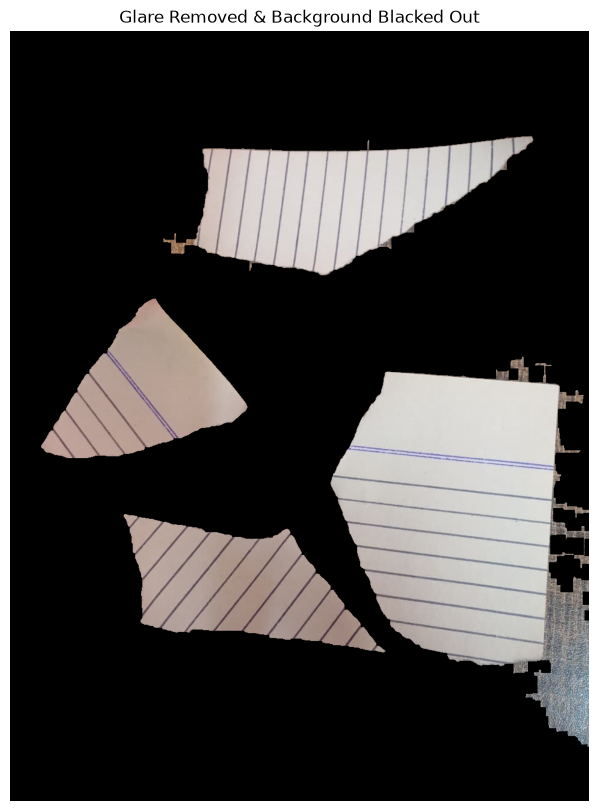

In [44]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def keep_paper_and_blackout_background(image_or_path):
    """Keeps the paper fragments intact while turning all background (including glare/reflections) black."""
    # 1. Load image
    if isinstance(image_or_path, str):
        img = cv2.imread(image_or_path)
        if img is None:
            print("Error: Could not load image.")
            return None
    else:
        img = image_or_path.copy()

    h, w, _ = img.shape

    # 2. Convert to HSV and LAB color spaces
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    s_channel = hsv[:, :, 1]  # Saturation
    l_channel = lab[:, :, 0]  # Lightness

    # 3. Smooth channels to reduce noise and handwriting details
    s_blur = cv2.GaussianBlur(s_channel, (9, 9), 0)
    l_blur = cv2.GaussianBlur(l_channel, (9, 9), 0)

    # 4. Thresholding:
    # Paper has LOW saturation (gray/white) AND HIGH lightness compared to wood
    _, low_sat = cv2.threshold(s_blur, 250, 255, cv2.THRESH_BINARY_INV)
    _, high_light = cv2.threshold(
        l_blur, 250, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Combine both conditions: Must be low saturation AND high lightness
    paper_mask_raw = cv2.bitwise_and(low_sat, high_light)

    # 5. Clean mask using morphological operations
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    cleaned_mask = cv2.morphologyEx(
        paper_mask_raw, cv2.MORPH_CLOSE, kernel_close
    )

    # 6. Extract paper contours and build solid filled mask
    contours, _ = cv2.findContours(
        cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    solid_paper_mask = np.zeros((h, w), dtype=np.uint8)
    min_area = (h * w) * 0.008

    for c in contours:
        if cv2.contourArea(c) > min_area:
            cv2.drawContours(
                solid_paper_mask, [c], -1, 255, thickness=cv2.FILLED
            )

    # 7. Apply solid mask to black out the entire background
    result = cv2.bitwise_and(img, img, mask=solid_paper_mask)

    return result


# Execute and plot
processed_img = keep_paper_and_blackout_background(r"D:\PythonProject1\Intern\Images\img156.jpeg")

plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
plt.title("Glare Removed & Background Blacked Out")
plt.axis("off")
plt.show()